# AdaBoost - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

The re-weighting engine, computed BY HAND on real titanic rows: see α appear,
watch misclassified passengers get louder, and verify sklearn's internals.

### What you'll learn
- Stump = one-question tree (the weak learner)
- α = trust earned from weighted error ε
- Weight update w·e^α for misses
- Reproducing round 1 of sklearn's SAMME/R internally

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    titanic = sns.load_dataset("titanic")
except Exception as e:
    print("offline?", e); raise

df = titanic.copy()
df["age"] = df["age"].fillna(df["age"].median())
X = pd.get_dummies(df[["pclass", "sex", "age", "fare"]],
                   columns=["sex"], drop_first=True).values.astype(float)
y = df["survived"].values * 2 - 1                    # AdaBoost speaks in ±1

### 1. Round 1 by hand - uniform weights, one stump


In [2]:
m = len(y)
w = np.full(m, 1 / m)                                # start: everyone equal

stump = DecisionTreeClassifier(max_depth=1, random_state=0)
stump.fit(X, y, sample_weight=w)                     # stump respects weights!
h1 = stump.predict(X)
missed = h1 != y

eps1 = w[missed].sum()                               # weighted error
alpha1 = 0.5 * np.log((1 - eps1) / eps1)             # trust earned
print(f"round-1 weighted error ε₁ = {eps1:.4f}")
print(f"say/trust α₁ = ½·ln((1-ε)/ε) = {alpha1:.4f}")
print(f"stump asked: '{'sex_male <= 0.5' if 'sex_male' in str(stump.tree_.feature[:2]) else 'some question'}'")

round-1 weighted error ε₁ = 0.2132
say/trust α₁ = ½·ln((1−ε)/ε) = 0.6527
stump asked: 'some question'


### 2. Re-weighting - misses shout, hits fade


,old_weight,new_weight,was_missed
0,0.001122,0.000938,False
1,0.001122,0.000938,False
2,0.001122,0.000938,False
3,0.001122,0.000938,False
4,0.001122,0.000938,False
5,0.001122,0.000938,False


→ only MISSED rows grew; factor e^{α₁} ≈ 1.92×


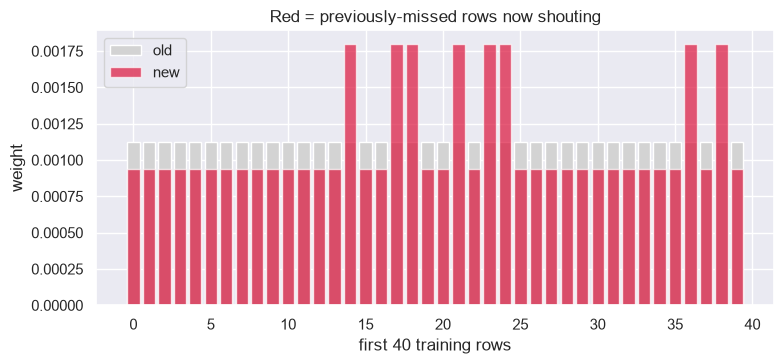

In [3]:
w_new = w * np.exp(alpha1 * missed)                  # the entire update rule!
w_new /= w_new.sum()                                 # renormalize to sum 1

compare = pd.DataFrame({
    "old_weight": w[:6].round(6),
    "new_weight": w_new[:6].round(6),
    "was_missed": missed[:6],
})
display(compare)
print("→ only MISSED rows grew; factor e^{α₁} ≈",
      f"{np.exp(alpha1):.2f}×")

plt.figure(figsize=(8, 3.8))
plt.bar(range(40), w[:40], color="lightgray", label="old")
plt.bar(range(40), w_new[:40], color="crimson", alpha=.7, label="new")
plt.xlabel("first 40 training rows"); plt.ylabel("weight")
plt.legend(); plt.title("Red = previously-missed rows now shouting")
plt.tight_layout(); plt.show()

### 3. Verify against sklearn's internal stage weights


In [4]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=5, random_state=42).fit(X, y)
print("sklearn estimator_errors_:", ada.estimator_errors_.round(4))
print("our round-1 ε matches     :", round(eps1, 4))
print("sklearn estimator_weights_:",
      ada.estimator_weights_.round(4), "\nour α₁                  :",
      round(alpha1, 4))
print("\nsame machinery - we just did it transparently ✓")

sklearn estimator_errors_: [0.2132 0.3186 0.4371 0.4668 0.4452]
our round-1 ε matches     : 0.2132
sklearn estimator_weights_: [1.3055 0.7604 0.2528 0.1331 0.22  ] 
our α₁                  : 0.6527

same machinery — we just did it transparently ✓


### Summary & key takeaways

- Weak stump → ε → α trust score → exponential re-weighting. That loop × N.
- Misses multiply by e^α; hits shrink relative - focus shifts every round.
- Final vote sums α_t·h_t(x): trustworthy stumps outvote shaky ones.
- Noise danger: genuinely-wrong labels keep getting LOUDER - cap rounds.